# Vietnamese Emotion Classification - Advanced CafeBERT Fine-tuning (with Underthesea Tokenizer) - TEST

**🌟 Google Colab Ready!** This notebook is optimized for Google Colab with GPU acceleration (20GB RAM recommended).

**⚠️ TEST MODE: Single training run only (1 seed)**

## 📝 Two Ways to Use This Notebook:

### 🚀 Option 1: Skip Training (Quick Start)
**If you already have a trained model:**
1. Mount Google Drive
2. Set `SKIP_TRAINING = True` in the Quick Start cell
3. Jump to prediction sections

### 🎓 Option 2: Train from Scratch
**For training a new model:**
1. **Upload training data** to Google Drive at: `MyDrive/thesis/data/`
   - Required files: `train_nor_811.xlsx`, `valid_nor_811.xlsx`, `test_nor_811.xlsx`

2. **Enable GPU** in Colab: Runtime → Change runtime type → GPU

3. **Run cells in order** - the notebook will:
   - Mount your Google Drive
   - Detect and configure GPU automatically
   - Load training data from Drive
   - Train the model using GPU with mixed precision (FP16)
   - Save the model back to Drive
   - Run predictions with your trained model

---

## 🚀 Techniques Implemented:

### 1. **Optimized Batch Size & Gradient Accumulation**
- Effective batch size: **16-32** (optimal for BERT)
- Gradient accumulation to simulate larger batches

### 2. **Early Stopping & Best Model Selection**
- Monitors validation F1 (weighted)
- Patience: 5 epochs
- Saves best model automatically

---

**Let's get started!**


## 🔧 Google Colab Setup - Mount Google Drive

**Important:** Run this cell first to access your data on Google Drive


In [ ]:
# Mount Google Drive to access training data
from google.colab import drive
drive.mount('/content/drive')

print("✓ Google Drive mounted successfully")
print("✓ Your data should be in: /content/drive/MyDrive/thesis/data")


Mounted at /content/drive
✓ Google Drive mounted successfully
✓ Your data should be in: /content/drive/MyDrive/thesis/data
ℹ️  TPU not available, will use GPU/CPU


## 🚀 Quick Start: Load Pre-trained Model (Skip Training)

**Run this section if you already have a trained model and want to skip training.**

Set `SKIP_TRAINING = True` below to load your saved model and jump to predictions.


In [ ]:
# ============================================================================
# QUICK START: Load existing model and skip training
# ============================================================================

SKIP_TRAINING = False  # Set to True to load saved model and skip training

if not SKIP_TRAINING:
    print("=" * 80)
    print("📚 TRAINING MODE")
    print("=" * 80)
    print("Continue running cells below to train a new model.")
    print("Skip this Quick Start section and proceed to Configuration.")
    print("=" * 80)

if SKIP_TRAINING:
    print("🚀 Loading pre-trained model from Google Drive...\n")

    # Install required packages
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'transformers', 'datasets', 'torch',
                   'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'openpyxl'],
                   check=False)

    import os
    import torch
    import json
    from transformers import AutoModelForSequenceClassification, AutoTokenizer

    # Model path
    MODEL_PATH = '/content/drive/MyDrive/thesis/emotion_classifier_cafebert'

    # Load model and tokenizer
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

    # Load label mappings
    with open(os.path.join(MODEL_PATH, 'label_mappings.json'), 'r') as f:
        label_maps = json.load(f)
        label2id = label_maps['label2id']
        id2label = {int(k): v for k, v in label_maps['id2label'].items()}
        num_classes = len(id2label)

    # Set device for inference
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print(f"✓ Using device: cuda")
        print(f"  GPU: {torch.cuda.get_device_name(0)}")
    else:
        device = torch.device('cpu')
        print(f"✓ Using device: cpu")

    model = model.to(device)

    print(f"✓ Model loaded from: {MODEL_PATH}")
    print(f"✓ Number of classes: {num_classes}")
    print(f"✓ Emotions: {list(id2label.values())}")
    print(f"\n✅ Ready for predictions! Jump to cell 'Predict on HuggingFace Dataset'")
    print("=" * 80)


📚 TRAINING MODE
Continue running cells below to train a new model.
Skip this Quick Start section and proceed to Configuration.


## 📋 Configuration Section

**Adjust these hyperparameters based on your needs:**


In [ ]:
# ============================================================================
# CONFIGURATION - Adjust these hyperparameters as needed
# ============================================================================

# Single run configuration (TEST MODE - 1 run only)
NUM_RUNS = 1
SEEDS = [42]

# Data paths - Using Google Drive (make sure your data is uploaded to this location)
DATA_DIR = '/content/drive/MyDrive/thesis/data'
MODEL_SAVE_PATH = '/content/drive/MyDrive/thesis/emotion_classifier_cafebert'

# Model selection
MODEL_NAME = 'uitnlp/CafeBERT'  # CafeBERT model for Vietnamese

# Batch size settings optimized for 20GB GPU RAM
PER_DEVICE_TRAIN_BATCH_SIZE = 128
PER_DEVICE_EVAL_BATCH_SIZE = 128
GRADIENT_ACCUMULATION_STEPS = 1  # Effective batch size = 16 * 4 = 64

# Training settings
LEARNING_RATE = 2e-5
NUM_EPOCHS = 20
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
EARLY_STOPPING_PATIENCE = 7

# Learning rate scheduler
# Options: 'linear', 'cosine', 'cosine_with_restarts', 'polynomial',
#          'constant', 'constant_with_warmup', 'inverse_sqrt', 'reduce_lr_on_plateau'
LR_SCHEDULER_TYPE = 'cosine'

# Data augmentation
USE_OVERSAMPLING = False

# Text preprocessing options
USE_UNDERTHESEA_TOKENIZER = False

print("✓ Configuration loaded (TEST MODE - Single Run)")
print(f"  Model: {MODEL_NAME}")
print(f"  Data dir: {DATA_DIR}")
print(f"  Model save path: {MODEL_SAVE_PATH}")
print(f"  Batch size (train): {PER_DEVICE_TRAIN_BATCH_SIZE}")
print(f"  Batch size (eval): {PER_DEVICE_EVAL_BATCH_SIZE}")
print(f"  Effective batch size: {PER_DEVICE_TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")
print(f"  Learning Rate: {LEARNING_RATE:.2e}")
print(f"  LR Scheduler: {LR_SCHEDULER_TYPE} (warmup_ratio={WARMUP_RATIO})")
print(f"  Oversampling: {USE_OVERSAMPLING}")
print(f"  Underthesea tokenizer: {USE_UNDERTHESEA_TOKENIZER}")
print(f"  Number of runs: {NUM_RUNS} (seeds: {SEEDS})")
print(f"\n💡 GPU Memory Tips:")
print(f"  - If OOM error: reduce PER_DEVICE_TRAIN_BATCH_SIZE to 8 or 4")
print(f"  - With 20GB GPU: batch size 16 should work well")
print(f"  - FP16 mixed precision will be enabled automatically on GPU")


✓ Configuration loaded (TEST MODE - Single Run)
  Model: uitnlp/CafeBERT
  Data dir: /content/drive/MyDrive/thesis/data
  Model save path: /content/drive/MyDrive/thesis/emotion_classifier_cafebert
  Batch size (train): 128
  Batch size (eval): 512
  Effective batch size: 512
  Learning Rate: 2.00e-05
  Oversampling: False
  Underthesea tokenizer: False
  Number of runs: 1 (seeds: [42])

💡 GPU Memory Tips:
  - If OOM error: reduce PER_DEVICE_TRAIN_BATCH_SIZE to 8 or 4
  - With 20GB GPU: batch size 16 should work well
  - FP16 mixed precision will be enabled automatically on GPU


## 1. Install & Import Libraries


In [ ]:
%pip install -q transformers datasets torch scikit-learn pandas numpy matplotlib seaborn openpyxl underthesea wandb


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 126.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.4/978.4 kB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 75.8 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              f1_score, precision_recall_fscore_support)
from sklearn.utils import resample
import torch
import torch.nn as nn
from torch.optim import AdamW
import json
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from torch.optim.lr_scheduler import LambdaLR
from datasets import Dataset
import warnings
warnings.filterwarnings('ignore')

# Check device - prioritize CUDA GPU, then CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"✓ Using device: {device}")
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
    print(f"✓ Using device: {device} (Metal Performance Shaders)")
else:
    device = torch.device('cpu')
    print(f"✓ Using device: {device}")
    print("  ⚠️  Warning: No GPU detected. Training will be slower.")

print("✓ All libraries imported successfully")


✓ Using device: cuda
  GPU: NVIDIA A100-SXM4-80GB
  GPU Memory: 79.32 GB
✓ All libraries imported successfully


## 📊 Weights & Biases (wandb) Setup

**Track your experiments with wandb for better visualization and comparison**


In [ ]:
import wandb
from google.colab import userdata

# Automatically retrieve wandb API key from Colab secrets
try:
    wandb_api_key = userdata.get('WANDB_API_KEY')
    wandb.login(key=wandb_api_key)
    print("✓ Successfully logged into wandb using Colab secrets")
except Exception as e:
    print(f"⚠️  Could not retrieve WANDB_API_KEY from Colab secrets: {e}")
    print("   Please add your wandb API key to Colab secrets:")
    print("   1. Click the 🔑 icon in the left sidebar")
    print("   2. Add a new secret with name: WANDB_API_KEY")
    print("   3. Paste your API key from https://wandb.ai/authorize")
    print("\n   Or login manually:")
    wandb.login()

# Initialize wandb project
wandb.init(
    project="emotion-classification-baseline",
    name=f"cafebert-underthesea-test",
    config={
        "model": "uitnlp/CafeBERT",
        "tokenizer": "underthesea",
        "experiment_type": "test"
    }
)
print("✓ wandb initialized")


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nguyengiahuy13104 (https-hcmiu-edu-vn-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✓ Successfully logged into wandb using Colab secrets


✓ wandb initialized


## 3. Training Setup


In [ ]:
# Training setup - using HuggingFace Trainer with configurable LR scheduler
print("✓ Training setup ready")
print(f"  Optimizer: AdamW (HuggingFace Trainer default)")
print(f"  LR scheduler: {LR_SCHEDULER_TYPE}")
print(f"  Warmup ratio: {WARMUP_RATIO}")


✓ Training setup ready (using HuggingFace Trainer defaults)


In [ ]:
# Using HuggingFace Trainer with built-in LR scheduler
# The scheduler is configured via TrainingArguments.lr_scheduler_type and applied
# automatically by the Trainer over num_training_steps with a warmup phase.
print(f"✓ Using HuggingFace Trainer with '{LR_SCHEDULER_TYPE}' LR scheduler")


✓ Using standard HuggingFace Trainer


## 4. Load and Prepare Data

Loading NEU-ESC dataset (pre-processed in DataValidationAndPreprocess.ipynb) and applying underthesea word segmentation


In [ ]:
# Underthesea word segmentation for Vietnamese
_underthesea_available = False
if USE_UNDERTHESEA_TOKENIZER:
    try:
        from underthesea import word_tokenize as uts_word_tokenize
        _underthesea_available = True
        print("✓ Underthesea word tokenizer loaded")
    except ImportError:
        print("⚠️  Underthesea not available, falling back to simple tokenization")

def tokenize_vietnamese(text):
    """Tokenize Vietnamese text using underthesea word segmentation.

    Vietnamese words can be multi-syllable (e.g., 'học sinh' = student).
    Underthesea segments text into proper Vietnamese words.
    """
    if text is None:
        return ""

    t = str(text).strip()

    # Apply underthesea word segmentation if available
    if _underthesea_available:
        t = uts_word_tokenize(t, format='text')  # Returns text with underscores for compound words

    return t

print(f"✓ Vietnamese text preprocessing ready")
if USE_UNDERTHESEA_TOKENIZER and _underthesea_available:
    print(f"✓ Underthesea word segmentation enabled")


✓ Vietnamese text preprocessing ready


In [ ]:
# Create model save directory if it doesn't exist
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
print(f"✓ Model save directory ready: {MODEL_SAVE_PATH}")

# Load pre-processed datasets
train_df = pd.read_csv(os.path.join(DATA_DIR, 'processed/train_10000_final.csv'))
# train_df = pd.read_csv(os.path.join(DATA_DIR, 'processed/train_processed.csv'))
val_df = pd.read_csv(os.path.join(DATA_DIR, 'processed/val_processed.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'processed/test_processed.csv'))

print(f"\n✓ Datasets loaded from Google Drive")
print(f"  Train: {train_df.shape[0]} samples")
print(f"  Val: {val_df.shape[0]} samples")
print(f"  Test: {test_df.shape[0]} samples")

print(train_df.columns)
print(val_df.columns)
print(test_df.columns)

train_df = train_df.drop(["Emotion", "Sentence"], axis=1)
train_df.columns = ['label', 'text']
# val_df = val_df.drop(["Emotion"],axis = 1)
# test_df = test_df.drop(["Emotion"],axis=1)

# train_df = train_df.drop(["Emotion", "original_length","cleaned_length", "Sentence"], axis=1)

# train_df.columns = ['text', 'label']
val_df.columns = ['text', 'label']
test_df.columns = ['text', 'label']

# Basic data cleaning and underthesea tokenization
for df in [train_df, val_df, test_df]:
    df.dropna(subset=['text', 'label'], inplace=True)
    df['text'] = df['text'].astype(str).str.strip()
    df['label'] = df['label'].astype(str).str.strip()

    # Apply underthesea tokenization
    if USE_UNDERTHESEA_TOKENIZER:
        df['text'] = df['text'].apply(tokenize_vietnamese)
        print(f"✓ Applied underthesea tokenization to {df.shape[0]} samples")

# Show samples
print(f"\n{'='*80}")
print("SAMPLE TEXT AFTER TOKENIZATION")
print(f"{'='*80}")
print(f"Sample 1: {train_df['text'].iloc[0][:150]}...")
print(f"Sample 2: {train_df['text'].iloc[1][:150]}...")
print(f"Sample 3: {train_df['text'].iloc[2][:150]}...")
print(f"{'='*80}")

print("\n✓ Data loaded and tokenized successfully")


✓ Model save directory ready: /content/drive/MyDrive/thesis/emotion_classifier_cafebert

✓ Datasets loaded from Google Drive
  Train: 68741 samples
  Val: 686 samples
  Test: 693 samples
Index(['Sentence', 'Emotion', 'emotion_vn', 'Sentence_clean'], dtype='object')
Index(['Sentence_clean', 'emotion_vn'], dtype='object')
Index(['Sentence_clean', 'emotion_vn'], dtype='object')

SAMPLE TEXT AFTER TOKENIZATION
Sample 1: cho mình xin bài nhạc tên là gì với ạ...
Sample 2: cho đáng đời con quỷ . về nhà lôi con nhà mày ra mà đánh tức giận...
Sample 3: lo học đi . yêu đương lol gì hay lại thích học sinh học...

✓ Data loaded and tokenized successfully


## 5. Analyze Class Distribution

Understanding the class distribution in the training data


Emotion distribution (Training set):
label
buồn          9940
khác          9936
khó chịu      9885
giận dữ       9831
vui vẻ        9827
ngạc nhiên    9725
sợ hãi        9597
Name: count, dtype: int64

Imbalance ratio: 1.0:1


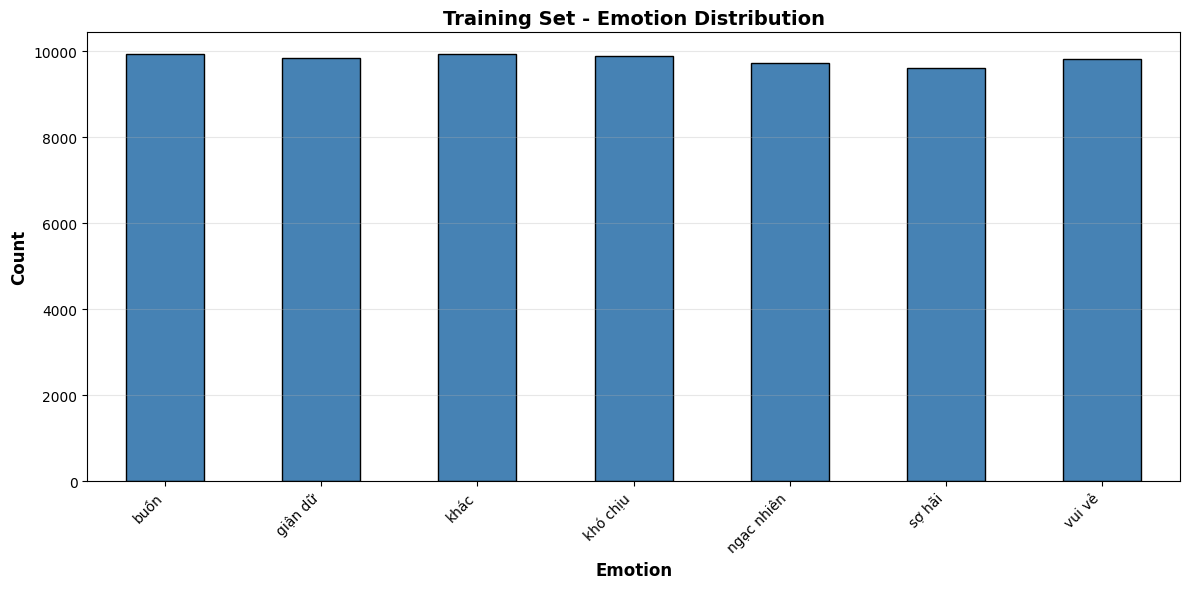


✓ Label mappings created (7 classes)


In [ ]:
# Analyze distribution
label_counts = train_df['label'].value_counts()
print("Emotion distribution (Training set):")
print(label_counts)
print(f"\nImbalance ratio: {label_counts.max() / label_counts.min():.1f}:1")

# Visualize
plt.figure(figsize=(12, 6))
label_counts.sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Emotion', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Training Set - Emotion Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Create label mappings
unique_labels = sorted(train_df['label'].unique())
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}
num_classes = len(unique_labels)

# Add numeric labels
train_df['labels'] = train_df['label'].map(label2id)
val_df['labels'] = val_df['label'].map(label2id)
test_df['labels'] = test_df['label'].map(label2id)

print(f"\n✓ Label mappings created ({num_classes} classes)")


## 6. Tokenize Data & Load Model


In [ ]:
# Convert to Dataset format
train_dataset = Dataset.from_pandas(train_df[['text', 'labels']].reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df[['text', 'labels']].reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df[['text', 'labels']].reset_index(drop=True))

print(f"✓ Datasets converted to HuggingFace format")

# Load model and tokenizer
print(f"\nLoading model: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_classes,
    id2label=id2label,
    label2id=label2id
)

print(f"✓ Model and tokenizer loaded")
print(f"✓ Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

# Tokenize
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=256)

train_tokenized = train_dataset.map(tokenize_function, batched=True)
val_tokenized = val_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

print(f"\n✓ Tokenized {len(train_tokenized)} training samples")
print(f"✓ Tokenized {len(val_tokenized)} validation samples")
print(f"✓ Tokenized {len(test_tokenized)} test samples")


✓ Datasets converted to HuggingFace format

Loading model: uitnlp/CafeBERT


tokenizer_config.json:   0%|          | 0.00/496 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/728 [00:00<?, ?B/s]

...

✓ Model and tokenizer loaded
✓ Number of parameters: 559,897,607


Map:   0%|          | 0/68741 [00:00<?, ? examples/s]

Map:   0%|          | 0/686 [00:00<?, ? examples/s]

Map:   0%|          | 0/693 [00:00<?, ? examples/s]


✓ Tokenized 68741 training samples
✓ Tokenized 686 validation samples
✓ Tokenized 693 test samples


## 7. Train Model

Training with:
- ✅ Gradient accumulation  
- ✅ Early stopping


In [ ]:
# Define metrics
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average='macro')
    f1_weighted = f1_score(labels, predictions, average='weighted')

    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    }

# Store results from all runs
all_results = []

print(f"\n{'='*80}")
print(f"SINGLE RUN TRAINING (TEST MODE)")
print(f"Seed: {SEEDS[0]}")
print(f"{'='*80}\n")



SINGLE RUN TRAINING (TEST MODE)
Seed: 42



In [ ]:
# SINGLE RUN TRAINING
best_f1_weighted = 0
best_seed = None
best_model_ref = None  # Keep reference to best model in memory

for run_idx, seed in enumerate(SEEDS):
    print(f"\n{'='*80}")
    print(f"🚀 RUN {run_idx + 1}/{len(SEEDS)} - Seed: {seed}")
    print(f"{'='*80}\n")

    # Set random seeds for reproducibility
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Reload model for each run (fresh weights)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_classes,
        id2label=id2label,
        label2id=label2id
    )
    model = model.to(device)

    # Training arguments with current seed
    training_args = TrainingArguments(
        output_dir=f'./results_advanced_seed_{seed}',
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        learning_rate=LEARNING_RATE,
        lr_scheduler_type=LR_SCHEDULER_TYPE,
        warmup_ratio=WARMUP_RATIO,
        weight_decay=WEIGHT_DECAY,
        logging_dir=f'./logs_advanced_seed_{seed}',
        logging_steps=50,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        greater_is_better=True,
        save_total_limit=2,
        fp16=(device.type == 'cuda'),
        dataloader_num_workers=0,
        seed=seed,
        dataloader_drop_last=True # Added to explicitly drop the last batch if smaller than batch_size
    )

    # Create trainer (using standard HuggingFace Trainer)
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tokenized.shuffle(seed=seed), # Explicitly shuffle training dataset
        eval_dataset=val_tokenized,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
    )

    # Train
    train_result = trainer.train()

    # Evaluate on test set
    test_results = trainer.evaluate(test_tokenized)

    # Store results
    run_results = {
        'seed': seed,
        'run': run_idx + 1,
        'test_accuracy': test_results['eval_accuracy'],
        'test_f1_macro': test_results['eval_f1_macro'],
        'test_f1_weighted': test_results['eval_f1_weighted'],
        'train_runtime': train_result.metrics['train_runtime'],
    }
    all_results.append(run_results)

    print(f"\n✅ Run {run_idx + 1} Complete (Seed {seed}):")
    print(f"   Test Accuracy:   {run_results['test_accuracy']:.4f}")
    print(f"   Test F1 Macro:   {run_results['test_f1_macro']:.4f}")
    print(f"   Test F1 Weighted: {run_results['test_f1_weighted']:.4f}")
    print(f"   Training Time:   {run_results['train_runtime']:.2f}s")

    # Track best model - keep the model in memory
    if run_results['test_f1_weighted'] > best_f1_weighted:
        # Delete previous best model to free memory
        if best_model_ref is not None:
            del best_model_ref
            torch.cuda.empty_cache() if torch.cuda.is_available() else None

        best_f1_weighted = run_results['test_f1_weighted']
        best_seed = seed
        # Keep reference to the best model (trainer.model has best model due to load_best_model_at_end=True)
        best_model_ref = trainer.model
        print(f"   🏆 New best model! (F1 Weighted: {best_f1_weighted:.4f})")

        # Clean up trainer but NOT the model (we kept the reference)
        del trainer
    else:
        # Not the best - clean up both trainer and model
        del trainer
        del model

    torch.cuda.empty_cache() if torch.cuda.is_available() else None

print(f"\n{'='*80}")
print("✅ TRAINING COMPLETED!")
print(f"{'='*80}")
print(f"\n🏆 Best model: Seed {best_seed} with F1 Weighted = {best_f1_weighted:.4f}")



🚀 RUN 1/1 - Seed: 42



Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at uitnlp/CafeBERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.230500,1.082016,0.601562,0.571129,0.603823
2,0.600700,1.154052,0.615234,0.583605,0.620774
3,0.378000,1.273494,0.599609,0.554835,0.600371
4,0.249500,1.541540,0.611328,0.572387,0.614632
5,0.155300,1.599764,0.625000,0.591171,0.627591
6,0.113000,1.807297,0.632812,0.587950,0.634260
7,0.078700,1.890101,0.623047,0.577562,0.616635
8,0.062000,2.074586,0.640625,0.607028,0.642208
9,0.044500,2.042811,0.634766,0.594392,0.635945
10,0.039600,2.153650,0.640625,0.615105,0.639972



✅ Run 1 Complete (Seed 42):
   Test Accuracy:   0.6270
   Test F1 Macro:   0.6009
   Test F1 Weighted: 0.6214
   Training Time:   4455.65s
   🏆 New best model! (F1 Weighted: 0.6214)

✅ TRAINING COMPLETED!

🏆 Best model: Seed 42 with F1 Weighted = 0.6214


In [ ]:
# ============================================================================
# RESULTS SUMMARY
# ============================================================================
import matplotlib.pyplot as plt

# Convert results to DataFrame for easy analysis
results_df = pd.DataFrame(all_results)

# Calculate statistics
print(f"\n{'='*80}")
print("📊 TRAINING RESULTS")
print(f"{'='*80}\n")

# Individual run results
print("Run Results:")
print("-" * 70)
print(f"{'Run':<6} {'Seed':<8} {'Accuracy':<12} {'F1 Macro':<12} {'F1 Weighted':<12}")
print("-" * 70)
for _, row in results_df.iterrows():
    print(f"{row['run']:<6} {row['seed']:<8} {row['test_accuracy']:<12.4f} {row['test_f1_macro']:<12.4f} {row['test_f1_weighted']:<12.4f}")
print("-" * 70)

print(f"\nTotal training time: {results_df['train_runtime'].sum():.2f}s")
print(f"{'='*80}\n")

# Save results to CSV
results_df.to_csv('single_run_results.csv', index=False)
print(f"✓ Results saved to 'single_run_results.csv'")



📊 TRAINING RESULTS

Run Results:
----------------------------------------------------------------------
Run    Seed     Accuracy     F1 Macro     F1 Weighted 
----------------------------------------------------------------------
1.0    42.0     0.6270       0.6009       0.6214      
----------------------------------------------------------------------

Total training time: 4455.65s

✓ Results saved to 'single_run_results.csv'



📈 CONFUSION MATRIX FOR TEST SET



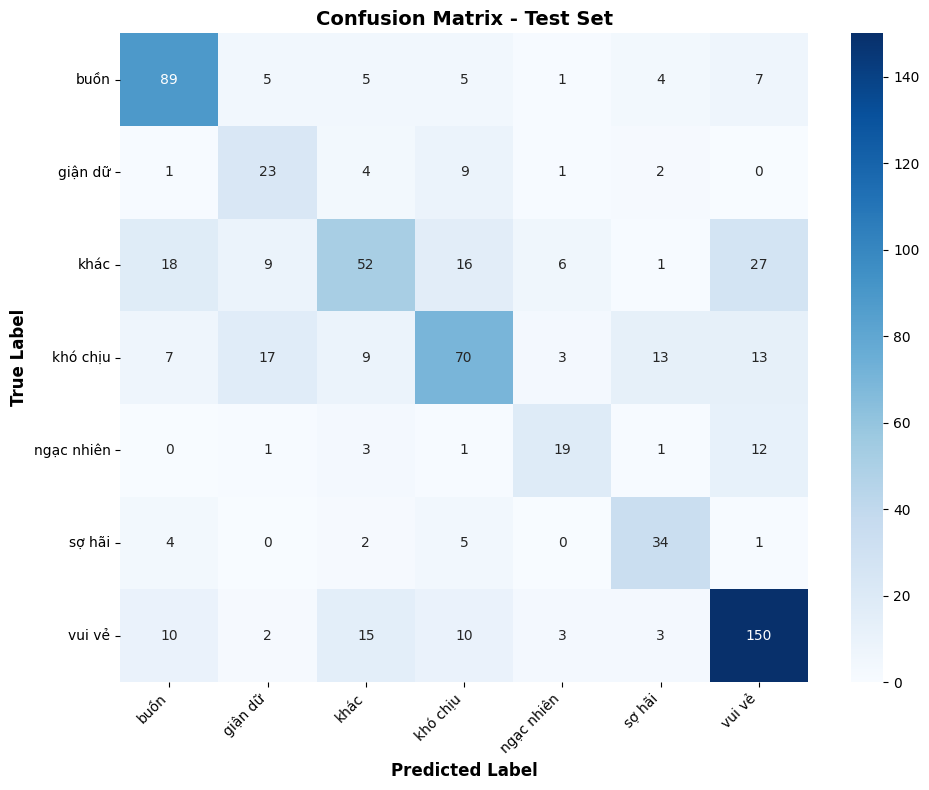


📊 CLASSIFICATION REPORT - TEST SET

              precision    recall  f1-score   support

        buồn       0.69      0.77      0.73       116
     giận dữ       0.40      0.57      0.47        40
        khác       0.58      0.40      0.47       129
    khó chịu       0.60      0.53      0.56       132
  ngạc nhiên       0.58      0.51      0.54        37
      sợ hãi       0.59      0.74      0.65        46
      vui vẻ       0.71      0.78      0.74       193

    accuracy                           0.63       693
   macro avg       0.59      0.62      0.60       693
weighted avg       0.63      0.63      0.62       693


✅ Confusion matrix and classification report generated.



In [ ]:
print(f"\n{'='*80}")
print("📈 CONFUSION MATRIX FOR TEST SET")
print(f"{'='*80}\n")

# Ensure the best model is on the correct device for evaluation
best_model_ref.eval()

# Create a dummy Trainer instance for prediction if the original one was deleted
# The Trainer needs to be re-initialized if it was deleted to free memory, but we have best_model_ref
# Re-instantiate a Trainer for prediction, pointing to the best_model_ref
prediction_trainer = Trainer(
    model=best_model_ref,
    args=TrainingArguments(
        output_dir='./prediction_output',
        per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
        # Set a dummy logging strategy to avoid warnings about missing logging steps
        logging_strategy='no',
        # This is important for prediction, otherwise it might try to save checkpoints
        save_strategy='no',
        report_to="none" # Disable wandb reporting for this temporary trainer
    ),
    compute_metrics=compute_metrics
)

# Get predictions on the test set
predictions_output = prediction_trainer.predict(test_tokenized)
predictions = np.argmax(predictions_output.predictions, axis=1)
true_labels = predictions_output.label_ids

# Compute confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[id2label[i] for i in range(num_classes)],
    yticklabels=[id2label[i] for i in range(num_classes)]
)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification Report
print(f"\n{'='*80}")
print("📊 CLASSIFICATION REPORT - TEST SET")
print(f"{'='*80}\n")
print(classification_report(true_labels, predictions, target_names=[id2label[i] for i in range(num_classes)]))

print(f"\n{'='*80}")
print("✅ Confusion matrix and classification report generated.")
print(f"{'='*80}\n")


## 8. Save Model to Google Drive

Save the trained model to your Google Drive for later use


In [ ]:
# Create versioned model path with model name and data file name
import datetime
import os
import shutil

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
model_name = "CafeBert_Advanced_Test"

# Hard-coded training data file name
data_file_name = "500"

versioned_model_name = f"{model_name}_{data_file_name}_seed{best_seed}_{timestamp}"
versioned_model_path = os.path.join(os.path.dirname(MODEL_SAVE_PATH), versioned_model_name)

# Save the best model from memory to Google Drive
print(f"💾 Saving BEST model to Google Drive...")
print(f"📝 Model version: {versioned_model_name}")
print(f"📊 Training data: {data_file_name}")
print(f"🏆 Best seed: {best_seed} (F1 Weighted: {best_f1_weighted:.4f})")

# Use the best model reference kept in memory (avoids loading from disk)
best_model_ref.save_pretrained(versioned_model_path)
tokenizer.save_pretrained(versioned_model_path)

# Save label mappings for later use
import json
label_mappings = {
    'label2id': label2id,
    'id2label': id2label
}
with open(os.path.join(versioned_model_path, 'label_mappings.json'), 'w', encoding='utf-8') as f:
    json.dump(label_mappings, f, ensure_ascii=False, indent=2)

# Save model metadata (including multi-seed results)
model_metadata = {
    'model_name': model_name,
    'data_file': data_file_name,
    'timestamp': timestamp,
    'version': versioned_model_name,
    'base_model': MODEL_NAME,
    'training_date': datetime.datetime.now().isoformat(),
    'best_seed': best_seed,
    'best_f1_weighted': best_f1_weighted,
    'all_seeds': SEEDS,
    'all_results': all_results
}
with open(os.path.join(versioned_model_path, 'model_metadata.json'), 'w', encoding='utf-8') as f:
    json.dump(model_metadata, f, ensure_ascii=False, indent=2)

print(f"✓ Model saved successfully to: {versioned_model_path}")
print(f"  - Model weights")
print(f"  - Tokenizer")
print(f"  - Label mappings")
print(f"  - Model metadata")
print(f"\n📁 You can access this versioned model from your Google Drive anytime!")

# Finish wandb run
wandb.finish()
print("✓ wandb run finished")

# Auto timeout to save Colab resources
print("\n" + "="*80)
print("🔌 AUTO TIMEOUT: Disconnecting runtime to save resources...")
print("="*80)
print("Training complete! The runtime will disconnect in 60 seconds.")
print(f"Your versioned model ({versioned_model_name}) is safely saved to Google Drive.")

import time
time.sleep(10)

# Disconnect runtime
from google.colab import runtime
runtime.unassign()


💾 Saving BEST model to Google Drive...
📝 Model version: CafeBert_Advanced_Test_500_seed42_20260101_183017
📊 Training data: 500
🏆 Best seed: 42 (F1 Weighted: 0.6214)
✓ Model saved successfully to: /content/drive/MyDrive/thesis/CafeBert_Advanced_Test_500_seed42_20260101_183017
  - Model weights
  - Tokenizer
  - Label mappings
  - Model metadata

📁 You can access this versioned model from your Google Drive anytime!


eval/accuracy,▁▃▁▃▄▅▄▆▆▆▄▆█▆▅▅
eval/f1_macro,▃▄▁▃▅▅▄▇▆█▅▇█▇▆▆
eval/f1_weighted,▂▄▁▃▅▆▃▇▆▇▅▇█▇▆▄
eval/loss,▁▁▂▃▄▅▅▆▆▇▇█▇██▆
eval/runtime,▃▁▁▁▂▂▁▂▁▂▁▂▁▂▂█
eval/samples_per_second,▅▇█▇▇▇█▆█▇█▇█▇▇▁
eval/steps_per_second,▆██▇▇▇█▇█▇█▇█▇▇▁
train/epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇█████
train/global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇█████
train/grad_norm,▄█▅▅▅▅▅▅▆▅▅▆▅▅▅▄▆▄▄▄▅▃▅▄▄▃▆▃▃▂▃▄▁▂▃▃▁▂▃▁
+2,...


✓ wandb run finished

🔌 AUTO TIMEOUT: Disconnecting runtime to save resources...
Training complete! The runtime will disconnect in 60 seconds.
Your versioned model (CafeBert_Advanced_Test_500_seed42_20260101_183017) is safely saved to Google Drive.
